# Rad sa nedostajućim vrednostima

U svesci će biti obrađene naredne metode rada sa nedostajućim vrednostima:

1.   Izbacivanje nedostajućih vrednosti 
2.   Popunjavanje default vrednostima
3.   Forward and backward fill
4.   Mean / median fill
5.   Mean / median fill with groupby
6.   Iterative imputation

Prikazano nad [Titanic skupom](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv) koji sadrži sledeće informacije o putnicima na Titaniku:

- <code>survived</code> - indikator da li su preživeli (0/1)
- <code>pclass</code> - putnička klasa (1/2/3; 1st=Upper, 2nd=Middle, 3rd=Lower)	
- <code>sex</code> - pol (male/female)	
- <code>age</code> - godine	
- <code>sibsp</code> - broj rođaka ili supružnika (SIBlings & SPouse) sa kojima su putovali (0/1/2/...)	
- <code>parch</code> - 	broj roditelja ili dece (PARents & CHidlren) sa kojima su putovali (0/1/2/...)
- <code>fare</code> - cena karte za brod	
- <code>embarked</code> - luka u kojoj su se ukrcali (C/Q/S; C=Cherbourg, Q=Queenstown, S=Southampton)	
- <code>class</code> - putnička klasa (First/Second/Third)	
- <code>who</code> - kateorija putnika (male/female/child)	
- <code>adult_male</code> - indikator da li je putnik muškog pola (True/False)	
- <code>deck</code> - kategorija putničke kabine (A/B/C/D/E/F/G/NaN)	
- <code>embark_town</code> - luka u kojoj su se ukrcali (Cherbourg/Queenstown/Southampton)	
- <code>alive</code> - indikator da li su preživeli (yes/no)	
- <code>alone</code> - indikator da li su putovali sami (True/False)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
titanic = sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Prvo proveravamo da li u skupu postoje nedostajuće vrednosti

In [4]:
#titanic.isna()
#titanic.isna().any()
titanic.isna().any().any()

True

U skupu postoje nedostajuće vrednosti. Koliko ih ima?

In [5]:
#Broj nedostajućih vrednosti
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Izbacivanje nedostajućih vrednosti

In [6]:
#Velicina pre izbacivanja
size_with_na = len(titanic)
size_with_na

891

In [7]:
#Velicina nakon izbacivanja
size_without_na = len(titanic.dropna())
size_without_na

182

In [8]:
#Izgubili smo 80 % skupa 
size_without_na/size_with_na * 100 

20.42648709315376

Pitanje: Da li izbaciti kolone koje imaju dosta nedostajućih vrednosti (kao što su <code>deck</code> ili <code>age</code>)?

## Popunjavanje default vrednostima

Još jedan naivan pristup



In [9]:
titanic['age'].fillna(0)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     0.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [10]:
titanic['deck'].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

Raspodela vrednosti... Šta izabrati kao default?

<Axes: >

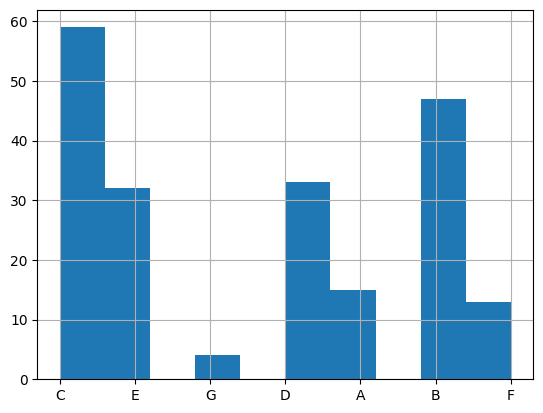

In [11]:
titanic['deck'].hist()

### Popunjavanje unapred/unazad

In [12]:
titanic['age'].ffill()

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    19.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [13]:
titanic['age'].bfill()

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    26.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [14]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: >

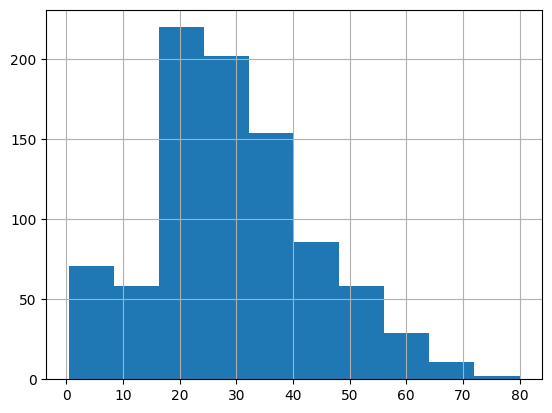

In [15]:
titanic['age'].ffill().hist()

Da li je ovo bolji pristup?

In [16]:
#Korelacija
titanic.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


<Axes: >

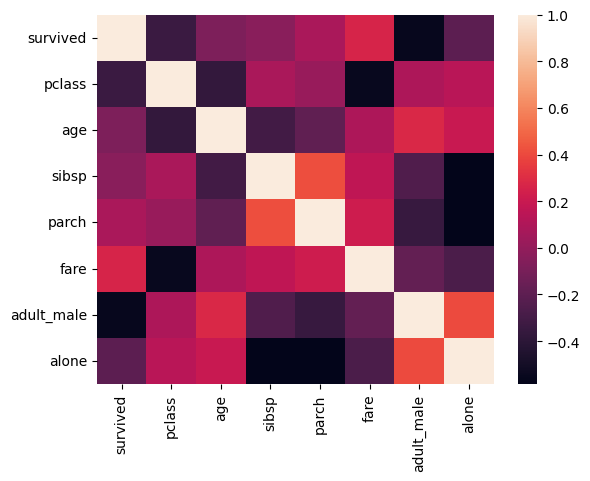

In [17]:
sns.heatmap(titanic.corr(numeric_only=True))

Na primer posmatramo <code>age</code> i <code>pclass</code> (nema nedostajuće vrednosti). Nemamo baš veliku korelaciju i možda nema smisla u ovoj situaciji, ali inače moze da bude ok pristup.

In [18]:
titanic[["age", "pclass"]].sort_values(by="pclass").ffill()['age']

445     4.0
310    24.0
309    30.0
307    17.0
306    17.0
       ... 
379    19.0
381     1.0
382    32.0
371    18.0
890    32.0
Name: age, Length: 891, dtype: float64

Uporedimo rezultate ova dva pristupa

In [19]:
count1, _ = np.histogram(titanic[["age", "pclass"]].sort_values(by="pclass").ffill()['age'])
count2, _ = np.histogram(titanic['age'].ffill())
count1, count2

(array([ 72,  58, 231, 214, 138,  89,  48,  29,  10,   2]),
 array([ 71,  58, 220, 202, 154,  86,  58,  29,  11,   2]))

### Mean / median fill

Problem sa ovim pristupom: potenicijalno mnogo identicnih vrednosti

<Axes: >

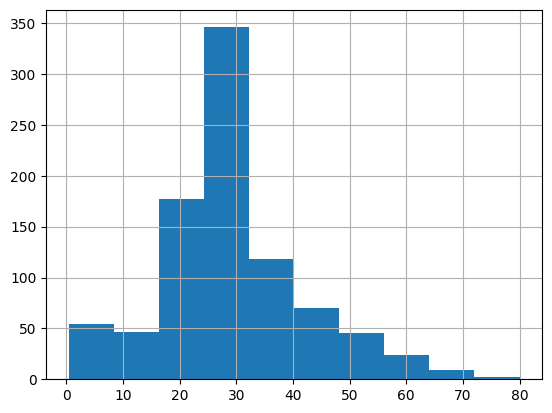

In [20]:
titanic['age'].fillna(titanic['age'].mean()).hist()

<Axes: >

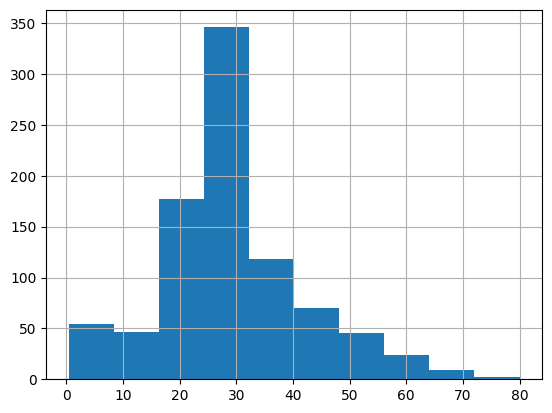

In [21]:
titanic['age'].fillna(titanic['age'].median()).hist()

## Mean/median with groupby 

In [22]:
# slicna intuicija kao u ffill sa pclass, samo popunjavamo srednjom vrednoscu svih iz iste grupe
titanic['age'].fillna(titanic.groupby(['pclass', 'sex'])['age'].transform('mean'))

0      22.00
1      38.00
2      26.00
3      35.00
4      35.00
       ...  
886    27.00
887    19.00
888    21.75
889    26.00
890    32.00
Name: age, Length: 891, dtype: float64

Primer rada sa kategoričkim atributom:

In [23]:
titanic['embark_town'] = titanic['embark_town'].astype('category')
titanic['embark_town'] = titanic['embark_town'].cat.codes
titanic['embark_town'] = titanic['embark_town'].fillna(titanic.groupby(['pclass', 'alive'])['embark_town'].transform('median'))

## Iterative imputation

Iterativna imputacija predstavlja proces predviđanja nedostajuće vrednosti gde se svaki atribut modeluje kao funkcija ostalih atributa.

Svaki atribut se predviđa sekvencijalno, jedan za drugim, pri čemu se i prethodno predviđene vrednosti koriste za predviđanje.

U pitanju je _iterativni_ proces, jer se isti postupak ponavlja više puta, omogućavajući poboljšanje predviđanja nedostajućih vrednosti - jer u kasnijim iteracijama postoje predviđene vrednosti za sve atribute.




In [24]:
# Dodatna literatura: https://sci2s.ugr.es/keel/pdf/specific/congreso/2010-zhang-efficient-data-imputation-ICCI2010.pdf
# https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
titanic1 = titanic[['survived', 'pclass', 'age', 'sibsp', 'fare', 'embark_town']]

imptr = IterativeImputer(RandomForestRegressor(), max_iter=100, tol=0.01, random_state=0)
titanic2 = pd.DataFrame(imptr.fit_transform(titanic1), columns = titanic1.columns)
titanic2

,survived,pclass,age,sibsp,fare,embark_town
0,0.0,3.0,22.000000,1.0,7.2500,2.0
1,1.0,1.0,38.000000,1.0,71.2833,0.0
2,1.0,3.0,26.000000,0.0,7.9250,2.0
3,1.0,1.0,35.000000,1.0,53.1000,2.0
4,0.0,3.0,35.000000,0.0,8.0500,2.0
...,...,...,...,...,...,...
886,0.0,2.0,27.000000,0.0,13.0000,2.0
887,1.0,1.0,19.000000,0.0,30.0000,2.0
888,0.0,3.0,32.162667,1.0,23.4500,2.0
889,1.0,1.0,26.000000,0.0,30.0000,0.0


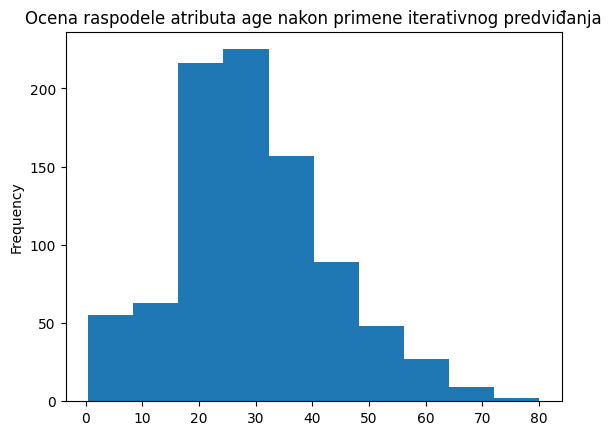

In [25]:
_ = titanic2['age'].plot(kind='hist', title='Ocena raspodele atributa age nakon primene iterativnog predviđanja')